In [1]:
import requests
import pandas as pd
from io import StringIO

START = "2019-10-01"
END   = "2019-12-10"

TILDE_SUMMARY = "https://tilde.geonet.org.nz/v4/dataSummary/"
TILDE_DATA    = "https://tilde.geonet.org.nz/v4/data/"

def get_json(url, params=None, timeout=60):
    r = requests.get(url, params=params, headers={"Accept": "application/json"}, timeout=timeout)
    r.raise_for_status()
    return r.json()

def get_csv_df(url, timeout=120):
    r = requests.get(url, headers={"Accept": "text/csv"}, timeout=timeout)
    r.raise_for_status()
    df = pd.read_csv(StringIO(r.text), parse_dates=["timestamp"])
    return df.set_index("timestamp").sort_index()

def tilde_data_url(domain, station, name, sensor, method, aspect, start=START, end=END):
    return f"{TILDE_DATA}{domain}/{station}/{name}/{sensor}/{method}/{aspect}/{start}/{end}"

## GeoNet

In [2]:
# the domain listing in the geonet website tells us the name/method/sensor/aspect vocabulary, 
# but we still need the station codes that correspond to Whakaari (White Island)
# this pulls stations for an exact (domain, name, method, aspect) and then filters by locality text

def stations_for(domain, name=None, method=None, aspect=None, station=None, verbose=False):
    params = {}
    if station is not None: params["station"] = station
    if name is not None:    params["name"] = name
    if method is not None:  params["method"] = method
    if aspect is not None:  params["aspect"] = aspect

    js = get_json(f"{TILDE_SUMMARY}{domain}", params=params)

    dom = js.get("domain", {}).get(domain)
    if dom is None:
        if verbose:
            print("No domain payload for:", domain, "params:", params)
            print("Top-level keys:", list(js.keys()))
            # Sometimes error payloads have message/detail fields
            for k in ["message", "detail", "error", "errors"]:
                if k in js:
                    print(k, ":", js[k])
        return {}

    return dom.get("stations", {})

def filter_whakaari(stations_dict):
    keys = ["whakaari", "white island"]
    out = {}
    for code, obj in stations_dict.items():
        loc = (obj.get("stationLocality") or "").lower()
        if any(k in loc for k in keys):
            out[code] = obj
    return out

### SO₂ flux (domain scandoas)

In [3]:
so2_st = filter_whakaari(stations_for("scandoas", name="gasflux", method="reviewed", aspect="SO2"))
so2_st

{'WID01': {'station': 'WID01',
  'stationLocality': 'Whakaari/White Island North-East Point',
  'latitude': -37.5167,
  'longitude': 177.193,
  'stationElevationM': 30,
  'sensorCodes': {'01': {'sensorCode': '01',
    'metadata': {'latitude': -37.5167, 'longitude': 177.193},
    'names': {'gasflux': {'name': 'gasflux',
      'methods': {'reviewed': {'method': 'reviewed',
        'aspects': {'SO2': {'aspect': 'SO2',
          'recordCount': 30009,
          'earliestRecord': '2009-11-13T03:43:24Z',
          'latestRecord': '2021-05-25T02:11:46Z'}}}}}}}}},
 'WID02': {'station': 'WID02',
  'stationLocality': 'Whakaari/White Island South Rim',
  'latitude': -37.5265,
  'longitude': 177.189,
  'stationElevationM': 65,
  'sensorCodes': {'01': {'sensorCode': '01',
    'metadata': {'latitude': -37.5265, 'longitude': 177.189},
    'names': {'gasflux': {'name': 'gasflux',
      'methods': {'reviewed': {'method': 'reviewed',
        'aspects': {'SO2': {'aspect': 'SO2',
          'recordCount': 2

In [4]:
# Download SO₂ flux (scanDOAS): WID01
# WID02 ends 2019-12-03, so it won’t cover to Dec 10

def tilde_data_url(domain, station, name, sensor, method, aspect, start=START, end=END):
    return f"{TILDE_DATA}{domain}/{station}/{name}/{sensor}/{method}/{aspect}/{start}/{end}"

# SO2 gas flux
so2_wid01 = get_csv_df(tilde_data_url("scandoas", "WID01", "gasflux", "01", "reviewed", "SO2"))
so2_wid01[["value"]].rename(columns={"value":"SO2_flux_WID01"}).head()

,SO2_flux_WID01
timestamp,
2019-10-01 01:44:35+00:00,18.884259
2019-10-01 01:49:01+00:00,9.641551
2019-10-01 01:53:28+00:00,7.573495
2019-10-01 01:57:54+00:00,9.699537
2019-10-01 02:11:05+00:00,7.828819


In [5]:
so2 = (
    so2_wid01[["value"]]
    .rename(columns={"value": "SO2_flux"})
)

so2.index = pd.to_datetime(so2.index, utc=True)
so2 = so2.sort_index()

In [6]:
#so2.to_csv("so2.csv", index=True)

### GNSS “Up” displacement (domain gnss)

In [7]:
gnss_st = filter_whakaari(stations_for("gnss", name="displacement", method="1d", aspect="up"))
gnss_st

{'RGWC': {'station': 'RGWC',
  'stationLocality': 'White Island Crater Floor',
  'latitude': -37.5243,
  'longitude': 177.1925,
  'stationElevationM': 37,
  'sensorCodes': {'nil': {'sensorCode': 'nil',
    'metadata': {'latitude': -37.5243, 'longitude': 177.1925},
    'names': {'displacement': {'name': 'displacement',
      'methods': {'1d': {'method': '1d',
        'aspects': {'up': {'aspect': 'up',
          'recordCount': 3103,
          'earliestRecord': '2014-01-30T11:59:00Z',
          'latestRecord': '2023-04-27T11:59:00Z'}}}}}}}}},
 'RGWI': {'station': 'RGWI',
  'stationLocality': 'White Island Summit',
  'latitude': -37.5181,
  'longitude': 177.1778,
  'stationElevationM': 292,
  'sensorCodes': {'nil': {'sensorCode': 'nil',
    'metadata': {'latitude': -37.5181, 'longitude': 177.1778},
    'names': {'displacement': {'name': 'displacement',
      'methods': {'1d': {'method': '1d',
        'aspects': {'up': {'aspect': 'up',
          'recordCount': 3621,
          'earliestRecor

In [8]:
# Download GNSS vertical displacement (“up”): RGWC and RGWI (crater floor + summit)

gnss_rgwc_up = get_csv_df(tilde_data_url("gnss", "RGWC", "displacement", "nil", "1d", "up"))
gnss_rgwi_up = get_csv_df(tilde_data_url("gnss", "RGWI", "displacement", "nil", "1d", "up"))

gnss_rgwc_up[["value"]].rename(columns={"value":"GNSS_up_RGWC"}).head()
#gnss_rgwi_up[["value"]].rename(columns={"value":"GNSS_up_RGWI"}).head()

,GNSS_up_RGWC
timestamp,
2019-10-01 11:59:00+00:00,-0.00516
2019-10-02 11:59:00+00:00,-0.00604
2019-10-03 11:59:00+00:00,-0.00300
2019-10-04 11:59:00+00:00,-0.00275
2019-10-05 11:59:00+00:00,-0.00207


In [9]:
# build the single deformation series from difference of the two GNSS series (RGWC - RGWI)

up_rgwc = gnss_rgwc_up["value"].rename("GNSS_up_RGWC")
up_rgwi = gnss_rgwi_up["value"].rename("GNSS_up_RGWI")

# Align on timestamps (daily)
gnss_up = pd.concat([up_rgwc, up_rgwi], axis=1).sort_index()

# Single deformation proxy time series
gnss_up["GNSS_up_diff"] = gnss_up["GNSS_up_RGWC"] - gnss_up["GNSS_up_RGWI"]

# Keep only the single variable (per your rule)
deformation = gnss_up[["GNSS_up_diff"]].copy()

display(deformation.head(), deformation.tail())
print("Missingness:", deformation.isna().mean().to_dict())

,GNSS_up_diff
timestamp,
2019-10-01 11:59:00+00:00,0.00963
2019-10-02 11:59:00+00:00,0.00881
2019-10-03 11:59:00+00:00,0.01156
2019-10-04 11:59:00+00:00,0.01214
2019-10-05 11:59:00+00:00,0.01302


,GNSS_up_diff
timestamp,
2019-12-06 11:59:00+00:00,0.01733
2019-12-07 11:59:00+00:00,0.02121
2019-12-08 11:59:00+00:00,0.01441
2019-12-09 11:59:00+00:00,0.01587
2019-12-10 11:59:00+00:00,0.01062


Missingness: {'GNSS_up_diff': 0.0}


In [10]:
gnss_up = pd.concat([up_rgwc, up_rgwi], axis=1)
up_diff = gnss_up["GNSS_up_RGWC"] - gnss_up["GNSS_up_RGWI"]

print("missing RGWC:", up_rgwc.isna().mean())
print("missing RGWI:", up_rgwi.isna().mean())
print("missing diff:", up_diff.isna().mean())

print("std RGWC:", up_rgwc.std())
print("std RGWI:", up_rgwi.std())
print("std diff:", up_diff.std())

missing RGWC: 0.0
missing RGWI: 0.0
missing diff: 0.0
std RGWC: 0.004669999564840845
std RGWI: 0.004598667443240609
std diff: 0.0030935288660477083


In [11]:
# finalize the single deformation series: crater inflation/deflation variable
gnss = up_diff.rename("GNSS_deformation").to_frame()

gnss.index = pd.to_datetime(gnss.index, utc=True)
gnss = gnss.sort_index()

### API & Pressure Drop (Open-Meteo) 

In [12]:
# pulls hourly precipitation + surface pressure + air temp at WID01 coordinates (lat/lon from your station metadata: -37.5167, 177.193)

LAT = -37.5167
LON = 177.193

START = "2019-10-01"
END   = "2019-12-10"

url = (
    "https://archive-api.open-meteo.com/v1/archive?"
    f"latitude={LAT}&longitude={LON}"
    f"&start_date={START}&end_date={END}"
    "&hourly=precipitation,surface_pressure"
    "&timezone=UTC"
)

r = requests.get(url)
r.raise_for_status()
data = r.json()

weather = pd.DataFrame({
    "timestamp": pd.to_datetime(data["hourly"]["time"]),
    "rainfall_mm": data["hourly"]["precipitation"],
    "surface_pressure_hPa": data["hourly"]["surface_pressure"],
}).set_index("timestamp").sort_index()

weather.head(), weather.tail()

(                     rainfall_mm  surface_pressure_hPa
 timestamp                                             
 2019-10-01 00:00:00          0.0                1005.0
 2019-10-01 01:00:00          0.4                1004.9
 2019-10-01 02:00:00          0.0                1004.0
 2019-10-01 03:00:00          0.1                1003.4
 2019-10-01 04:00:00          0.0                1003.0,
                      rainfall_mm  surface_pressure_hPa
 timestamp                                             
 2019-12-10 19:00:00          0.0                1007.9
 2019-12-10 20:00:00          0.0                1007.9
 2019-12-10 21:00:00          0.0                1007.7
 2019-12-10 22:00:00          0.0                1007.0
 2019-12-10 23:00:00          0.0                1006.5)

In [13]:
# Pressure tendency (hourly change) 
weather["pressure_change"] = weather["surface_pressure_hPa"].diff()
# pressure drop (negative change) 
weather["pressure_drop"] = -weather["pressure_change"]

# 24h rolling rainfall (classic hydro trigger metric)
weather["rain_24h_sum"] = weather["rainfall_mm"].rolling(24, min_periods=1).sum()

# Antecedent Precipitation Index (exponential decay)
# 1 / alpha ≈ 10 hours
# alpha = 0.05 → ~20 hour memory is more meaningful
weather["API"] = weather["rainfall_mm"].ewm(alpha=0.05).mean()

weather = weather.dropna()
weather.head()

,rainfall_mm,surface_pressure_hPa,pressure_change,pressure_drop,rain_24h_sum,API
timestamp,,,,,,
2019-10-01 01:00:00,0.4,1004.9,-0.1,0.1,0.4,0.205128
2019-10-01 02:00:00,0.0,1004.0,-0.9,0.9,0.4,0.133216
2019-10-01 03:00:00,0.1,1003.4,-0.6,0.6,0.5,0.124263
2019-10-01 04:00:00,0.0,1003.0,-0.4,0.4,0.5,0.096798
2019-10-01 05:00:00,0.0,1003.1,0.1,-0.1,0.5,0.078528


In [14]:
# from this we will keep API & pressure drop. for volcanic hydrothermal systems like Whakaari: 
# API is more physically realistic. It encodes cumulative stress build-up rather than a hard cutoff window.

weather_vars = weather[[
    #"rainfall_mm",
    #"rain_24h_sum",
    "API",
    "pressure_drop"
]].copy()

weather_vars.index = pd.to_datetime(weather_vars.index, utc=True)
weather_vars = weather_vars.sort_index()

## FDSN

In [15]:
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
from obspy import read_inventory
from obspy import Stream

import numpy as np

client = Client("GEONET")

### Stations

In [16]:
#station metadata
inventory = client.get_stations(latitude=-37.52,longitude=177.18,maxradius=0.2, starttime = "2019-10-01 00:00:00.000",endtime = "2019-12-10 00:00:00.000")
print(inventory)

Inventory created at 2026-04-27T00:58:34.000000Z
	Created by: Delta
		    
	Sending institution: GeoNet (WEL(GNS))
	Contains:
		Networks (1):
			NZ
		Stations (3):
			NZ.WI227 (White Island Fumarole 13)
			NZ.WIZ (White Island)
			NZ.WSRZ (White Island Summit)
		Channels (0):



WIZ: A broadband seismic station located on the southeast flank of the island. \
WSRZ: A seismic station located closer to the top crater rim, which provided higher signal-to-noise ratio data compared to WIZ.

In [17]:
inventory = client.get_stations(station="WSRZ",level="response",
                                starttime = "2019-10-01 00:00:00.000",endtime = "2019-12-10 00:00:00.000")
print(inventory)

Inventory created at 2026-04-27T00:58:34.000000Z
	Created by: Delta
		    
	Sending institution: GeoNet (WEL(GNS))
	Contains:
		Networks (1):
			NZ
		Stations (1):
			NZ.WSRZ (White Island Summit)
		Channels (12):
			NZ.WSRZ.10.HHZ, NZ.WSRZ.10.HHN, NZ.WSRZ.10.HHE, NZ.WSRZ.10.LHZ, 
			NZ.WSRZ.10.LHN, NZ.WSRZ.10.LHE, NZ.WSRZ.30.HDF, NZ.WSRZ.30.LDF, 
			NZ.WSRZ.33.HDF, NZ.WSRZ.33.LDF, NZ.WSRZ.34.HDF, NZ.WSRZ.34.LDF


In [18]:
network = inventory[0]
station = network[0] 
num_channels = len(station)
print ('number of channels: ', num_channels)
print(station)

number of channels:  12
Station WSRZ (White Island Summit)
	Station Code: WSRZ
	Channel Count: 12/30 (Selected/Total)
	2013-04-08T00:00:00.000000Z - 2023-12-01T00:00:00.000000Z
	Access: open 
	Latitude: -37.5181, Longitude: 177.1778, Elevation: 292.4 m
	Available Channels:
	  .33.HDF       100.0 Hz  2018-05-28 to 2023-12-01
	  .34.HDF       100.0 Hz  2018-05-28 to 2023-12-01
	  .30.HDF       100.0 Hz  2017-06-02 to 2023-12-01
	  .10.HH[ZNE]   100.0 Hz  2017-02-27 to 2023-12-01
	  .33.LDF         1.0 Hz  2018-05-28 to 2023-12-01
	  .34.LDF         1.0 Hz  2018-05-28 to 2023-12-01
	  .30.LDF         1.0 Hz  2017-06-02 to 2023-12-01
	  .10.LH[ZNE]     1.0 Hz  2017-02-27 to 2023-12-01



In [19]:
channel = station[0] # equivalent to inventory[0][0][0]
print(channel)

Channel 'HHE', Location '10' 
	Time range: 2017-02-27T00:10:01.000000Z - 2023-12-01T00:00:00.000000Z
	Latitude: -37.5181, Longitude: 177.1778, Elevation: 290.4 m, Local Depth: 0.0 m
	Azimuth: 90.00 degrees from north, clockwise
	Dip: 0.00 degrees down from horizontal
	Channel types: CONTINUOUS, GEOPHYSICAL
	Sampling Rate: 100.00 Hz
	Sensor (Description): Broadband Seismometer (Guralp CMG-3ESPC Broadband Seismometer)
	Response information available


### WSRZ

extracting four series from WSRZ:

- Hydrothermal tremor RMS 2–5 Hz
- Spectral ratio 4.5–8 Hz / 8–16 Hz
- HF event rate 5–10 Hz
- HF event rate 8–16 Hz

In [20]:
NETWORK = "NZ"
STATION = "WSRZ"
LOCATION = "10"
CHANNEL = "HHZ"

def get_day_trace(day_start):
    t1 = UTCDateTime(day_start)
    t2 = t1 + 24*3600

    st = client.get_waveforms(
        NETWORK, STATION, LOCATION, CHANNEL, t1, t2,
        attach_response=True
    )

    st.merge(fill_value="interpolate")
    tr = st[0]
    tr.detrend("linear")
    tr.detrend("demean")
    tr.taper(max_percentage=0.02)
    tr.remove_response(output="VEL")
    return tr

In [21]:
# helper: RMS in a band. this will be used for: 2–5 Hz RMS, 4.5–8 Hz RMS, 8–16 Hz RMS. 
# using 10-minute windows (600 seconds) -> each RMS value summarizes 10 minutes of seismic energy

def band_rms_series(trace, fmin, fmax, win_sec=600):
    tr = trace.copy()
    tr.filter("bandpass", freqmin=fmin, freqmax=fmax, corners=4, zerophase=True)

    sr = tr.stats.sampling_rate
    nwin = int(win_sec * sr)
    x = tr.data.astype(float)

    times, vals = [], []
    for i in range(0, len(x) - nwin + 1, nwin):
        seg = x[i:i+nwin]
        rms = np.sqrt(np.mean(seg**2))
        times.append(tr.stats.starttime + i / sr)
        vals.append(rms)

    return pd.Series(
        vals,
        index=pd.to_datetime([t.datetime for t in times])
    )

In [22]:
# Hydrothermal tremor RMS 2–5 Hz
# direct hydrothermal-state variable
def hydro_rms_2_5(trace, win_sec=600):
    s = band_rms_series(trace, 2.0, 5.0, win_sec=win_sec)
    s.name = "hydro_rms_2_5"
    return s

In [23]:
# Spectral ratio 4.5–8 / 8–16 Hz
# Whakaari-specific precursor/state variable
def spectral_ratio_4p5_8_over_8_16(trace, win_sec=600):
    low = band_rms_series(trace, 4.5, 8.0, win_sec=win_sec)
    high = band_rms_series(trace, 8.0, 16.0, win_sec=win_sec)

    ratio = low / high.replace(0, np.nan)
    ratio.name = "ratio_4p5_8_over_8_16"
    return ratio

In [24]:
# Continuous effect variable: eruption/tremor response energy
# Uses 5–15 Hz to avoid directly containing hydro_rms_2_5 as a sub-band.
def effect_tremor_rms_5_15(trace, win_sec=600):
    s = band_rms_series(trace, 5.0, 15.0, win_sec=win_sec)
    s.name = "effect_tremor_rms_5_15"
    return s

In [25]:
# HF event rate in 2–5 Hz only
from obspy.signal.trigger import classic_sta_lta, trigger_onset

def hf_event_rate_2_5(trace,
                      sta_sec=1.0,
                      lta_sec=5.0,
                      on_thres=3.0,
                      off_thres=1.5,
                      out_freq="1h"):
    tr = trace.copy()
    tr.filter("bandpass", freqmin=2.0, freqmax=5.0, corners=4, zerophase=True)

    sr = tr.stats.sampling_rate
    cft = classic_sta_lta(
        tr.data.astype(float),
        int(sta_sec * sr),
        int(lta_sec * sr)
    )

    on_off = trigger_onset(cft, on_thres, off_thres)

    event_times = []
    for on, off in on_off:
        event_times.append(tr.stats.starttime + on / sr)

    if len(event_times) == 0:
        idx = pd.date_range(
            pd.to_datetime(tr.stats.starttime.datetime).floor(out_freq),
            pd.to_datetime(tr.stats.endtime.datetime).floor(out_freq),
            freq=out_freq
        )
        return pd.Series(0, index=idx, name="hf_event_rate_2_5")

    event_times = pd.to_datetime([t.datetime for t in event_times])

    s = (
        pd.Series(1, index=event_times)
        .resample(out_freq)
        .sum()
        .fillna(0)
    )
    s.name = "hf_event_rate_2_5"
    return s

In [26]:
# Extract all features for one day
def extract_features_for_day(day_start):
    tr = get_day_trace(day_start)

    hydro = hydro_rms_2_5(tr, win_sec=600)
    ratio = spectral_ratio_4p5_8_over_8_16(tr, win_sec=600)
    hf_rate = hf_event_rate_2_5(tr, out_freq="1h")
    effect = effect_tremor_rms_5_15(tr, win_sec=600)

    # Put continuous waveform features on hourly grid for merging
    hydro_h = hydro.resample("1h").mean()
    ratio_h = ratio.resample("1h").mean()
    effect_h = effect.resample("1h").mean()

    df = pd.concat([hydro_h, ratio_h, hf_rate, effect_h], axis=1)
    return df

In [27]:
# Run over the full Whakaari window
days = pd.date_range("2019-10-01", "2019-12-10", freq="D")

all_days = []
for day in days:
    try:
        df_day = extract_features_for_day(day)
        all_days.append(df_day)
        print("done:", day.date())
    except Exception as e:
        print("failed:", day.date(), e)

waveform_df = pd.concat(all_days).sort_index()
waveform_df = waveform_df[~waveform_df.index.duplicated(keep="first")]

waveform_df.head(), waveform_df.tail()

done: 2019-10-01
done: 2019-10-02
done: 2019-10-03
done: 2019-10-04
done: 2019-10-05
done: 2019-10-06
done: 2019-10-07
done: 2019-10-08
done: 2019-10-09
done: 2019-10-10
done: 2019-10-11
done: 2019-10-12
done: 2019-10-13
done: 2019-10-14
done: 2019-10-15
done: 2019-10-16
done: 2019-10-17
done: 2019-10-18
done: 2019-10-19
done: 2019-10-20
done: 2019-10-21
done: 2019-10-22
done: 2019-10-23
done: 2019-10-24
done: 2019-10-25
done: 2019-10-26
done: 2019-10-27
done: 2019-10-28
done: 2019-10-29
done: 2019-10-30
done: 2019-10-31
done: 2019-11-01
done: 2019-11-02
done: 2019-11-03
done: 2019-11-04
done: 2019-11-05
done: 2019-11-06
done: 2019-11-07
done: 2019-11-08
done: 2019-11-09
done: 2019-11-10
done: 2019-11-11
done: 2019-11-12
done: 2019-11-13
done: 2019-11-14
done: 2019-11-15
done: 2019-11-16
done: 2019-11-17
done: 2019-11-18
done: 2019-11-19
done: 2019-11-20
done: 2019-11-21
done: 2019-11-22
done: 2019-11-23
done: 2019-11-24
done: 2019-11-25
done: 2019-11-26
done: 2019-11-27
done: 2019-11-

(                     hydro_rms_2_5  ratio_4p5_8_over_8_16  hf_event_rate_2_5  \
 2019-10-01 00:00:00       0.000002               1.932112                1.0   
 2019-10-01 01:00:00       0.000002               1.756227                1.0   
 2019-10-01 02:00:00       0.000002               1.978038                3.0   
 2019-10-01 03:00:00       0.000002               1.620937                1.0   
 2019-10-01 04:00:00       0.000002               1.769957                1.0   
 
                      effect_tremor_rms_5_15  
 2019-10-01 00:00:00                0.000002  
 2019-10-01 01:00:00                0.000004  
 2019-10-01 02:00:00                0.000004  
 2019-10-01 03:00:00                0.000004  
 2019-10-01 04:00:00                0.000004  ,
                      hydro_rms_2_5  ratio_4p5_8_over_8_16  hf_event_rate_2_5  \
 2019-12-10 19:00:00       0.000007               1.609068               28.0   
 2019-12-10 20:00:00       0.000006               1.677875         

In [28]:
waveform_df.columns

Index(['hydro_rms_2_5', 'ratio_4p5_8_over_8_16', 'hf_event_rate_2_5',
       'effect_tremor_rms_5_15'],
      dtype='object')

In [29]:
print(waveform_df.isna().mean())
waveform_df.describe()

hydro_rms_2_5             0.000000
ratio_4p5_8_over_8_16     0.000000
hf_event_rate_2_5         0.001176
effect_tremor_rms_5_15    0.000000
dtype: float64


,hydro_rms_2_5,ratio_4p5_8_over_8_16,hf_event_rate_2_5,effect_tremor_rms_5_15
count,1.700000e+03,1700.000000,1698.000000,1.700000e+03
mean,1.945570e-06,1.641214,7.660188,3.891592e-06
std,7.967279e-07,0.465081,7.185517,1.219615e-06
min,4.953468e-07,0.495936,0.000000,9.023087e-07
25%,1.468574e-06,1.343117,3.000000,3.002514e-06
50%,1.679596e-06,1.741087,6.000000,3.780905e-06
75%,2.340319e-06,1.946830,10.000000,4.564779e-06
max,7.377315e-06,2.986552,65.000000,1.231605e-05


In [30]:
wave = waveform_df.copy()

wave["hf_event_rate_2_5"] = wave["hf_event_rate_2_5"].fillna(0) # no events detected in that hour -> 0 rate

wave.index = pd.to_datetime(wave.index, utc=True)
wave = wave.sort_index()

## Final Dataset

In [115]:
MASTER_FREQ = "1h"

master_index = pd.date_range(
    start="2019-10-01",
    end="2019-12-10 23:00",
    freq=MASTER_FREQ,
    tz="UTC"
)

In [116]:
# resampling to hourly grid 
wave_1h = wave.resample(MASTER_FREQ).mean()
weather_1h = weather_vars.resample(MASTER_FREQ).interpolate()
so2_1h = so2.resample(MASTER_FREQ).mean()
gnss_1h = gnss.resample("1D").mean().resample(MASTER_FREQ).ffill()


In [117]:
# Align everything to the same timeline
wave_1h = wave_1h.reindex(master_index)
weather_1h = weather_1h.reindex(master_index)
so2_1h = so2_1h.reindex(master_index)
gnss_1h = gnss_1h.reindex(master_index)

In [118]:
# merge everything
master_df = pd.concat(
    [
        wave_1h,
        weather_1h,
        so2_1h,
        gnss_1h
    ],
    axis=1
)

master_df.index.name = "timestamp"

In [119]:
print(master_df.shape)

print("\nMissing fraction:")
print(master_df.isna().mean().sort_values())

master_df.head()

(1704, 8)

Missing fraction:
pressure_drop             0.000587
API                       0.000587
hydro_rms_2_5             0.002347
ratio_4p5_8_over_8_16     0.002347
effect_tremor_rms_5_15    0.002347
hf_event_rate_2_5         0.002347
GNSS_deformation          0.013498
SO2_flux                  0.874413
dtype: float64


,hydro_rms_2_5,ratio_4p5_8_over_8_16,hf_event_rate_2_5,effect_tremor_rms_5_15,API,pressure_drop,SO2_flux,GNSS_deformation
timestamp,,,,,,,,
2019-10-01 00:00:00+00:00,0.000002,1.932112,1.0,0.000002,NaN,NaN,NaN,0.00963
2019-10-01 01:00:00+00:00,0.000002,1.756227,1.0,0.000004,0.205128,0.1,11.449711,0.00963
2019-10-01 02:00:00+00:00,0.000002,1.978038,3.0,0.000004,0.133216,0.9,7.253356,0.00963
2019-10-01 03:00:00+00:00,0.000002,1.620937,1.0,0.000004,0.124263,0.6,5.393981,0.00963
2019-10-01 04:00:00+00:00,0.000002,1.769957,1.0,0.000004,0.096798,0.4,NaN,0.00963


In [120]:
# Keep eruption time as metadata only, not as a variable
eruption_time = pd.Timestamp("2019-12-09 01:11", tz="UTC")

In [121]:
# create final dataset 
analysis_df = master_df.copy()

analysis_df["SO2_flux"] = analysis_df["SO2_flux"].interpolate(limit=3)
analysis_df["API"] = analysis_df["API"].interpolate()
analysis_df["pressure_drop"] = analysis_df["pressure_drop"].fillna(0)
analysis_df["hf_event_rate_2_5"] = analysis_df["hf_event_rate_2_5"].fillna(0)
analysis_df["GNSS_deformation"] = analysis_df["GNSS_deformation"].ffill()
analysis_df["effect_tremor_rms_5_15"] = analysis_df["effect_tremor_rms_5_15"].interpolate()

In [122]:
analysis_df = analysis_df.dropna(
    subset=[
        "hydro_rms_2_5",
        "ratio_4p5_8_over_8_16",
        "hf_event_rate_2_5",
        "effect_tremor_rms_5_15"
    ]
)

In [123]:
analysis_df.describe()
analysis_df.isna().mean()
analysis_df.shape

(1700, 8)

In [124]:
from sklearn.preprocessing import StandardScaler

analysis_prepped = analysis_df.copy()

# Log-transform skewed positive variables
for col in ["SO2_flux", "hydro_rms_2_5", "hf_event_rate_2_5", "API", "effect_tremor_rms_5_15"]:
    if col in analysis_prepped.columns:
        analysis_prepped[col] = np.log1p(analysis_prepped[col].clip(lower=0))

feature_cols = analysis_prepped.columns.tolist()

scaler = StandardScaler()
analysis_scaled = analysis_prepped.copy()
analysis_scaled[feature_cols] = scaler.fit_transform(analysis_prepped[feature_cols])

analysis_scaled.head()

,hydro_rms_2_5,ratio_4p5_8_over_8_16,hf_event_rate_2_5,effect_tremor_rms_5_15,API,pressure_drop,SO2_flux,GNSS_deformation
timestamp,,,,,,,,
2019-10-01 00:00:00+00:00,-0.472424,0.625663,-1.443417,-1.157736,NaN,0.003868,NaN,-1.061989
2019-10-01 01:00:00+00:00,0.505494,0.247370,-1.443417,-0.099111,0.695580,0.215981,1.569699,-1.061989
2019-10-01 02:00:00+00:00,0.691205,0.724440,-0.584306,-0.139071,0.276171,1.912888,0.933823,-1.061989
2019-10-01 03:00:00+00:00,0.655976,-0.043612,-1.443417,0.075680,0.222097,1.276548,0.538969,-1.061989
2019-10-01 04:00:00+00:00,0.623237,0.276901,-1.443417,-0.043307,0.053499,0.852321,0.618739,-1.061989


In [125]:
# save all versions
master_df.to_pickle("../whakaari_data/whakaari_raw.pkl")
analysis_df.to_pickle("../whakaari_data/whakaari_dataset.pkl")
analysis_scaled.to_pickle("../whakaari_data/whakaari_dataset_scaled.pkl")

analysis_df.to_csv("../whakaari_data/whakaari_dataset.csv")
analysis_scaled.to_csv("../whakaari_data/whakaari_dataset_scaled.csv")

In [126]:
# load from checkpoint
#master_df = pd.read_pickle("../whakaari_data/whakaari_raw.pkl")
analysis_df = pd.read_pickle("../whakaari_data/whakaari_dataset.pkl")
analysis_scaled = pd.read_pickle("../whakaari_data/whakaari_dataset_scaled.pkl") 

Candidate causes: \
hydro_rms_2_5 \
ratio_4p5_8_over_8_16 \
SO2_flux \
GNSS_deformation 

Candidate triggers: \
hf_event_rate_2_5 \
API \
pressure_drop 

Effect: \
effect_tremor_rms_5_15

## Checks

In [127]:
def dataset_health_report(df, name):
    print(f"\n{name}")
    print("shape:", df.shape)
    print("duplicate timestamps:", df.index.duplicated().sum() if df.index.name == "timestamp" else df["timestamp"].duplicated().sum())
    print("time sorted:", df.index.is_monotonic_increasing if df.index.name == "timestamp" else df["timestamp"].is_monotonic_increasing)

    print("\nMissing fraction:")
    print(df.isna().mean().sort_values())

    print("\nDescribe:")
    display(df.describe())


In [128]:
dataset_health_report(master_df, "Whakaari master_df")
dataset_health_report(analysis_df, "Whakaari analysis_df")
dataset_health_report(analysis_scaled, "Whakaari analysis_scaled")


Whakaari master_df
shape: (1704, 8)
duplicate timestamps: 0
time sorted: True

Missing fraction:
pressure_drop             0.000587
API                       0.000587
hydro_rms_2_5             0.002347
ratio_4p5_8_over_8_16     0.002347
effect_tremor_rms_5_15    0.002347
hf_event_rate_2_5         0.002347
GNSS_deformation          0.013498
SO2_flux                  0.874413
dtype: float64

Describe:


,hydro_rms_2_5,ratio_4p5_8_over_8_16,hf_event_rate_2_5,effect_tremor_rms_5_15,API,pressure_drop,SO2_flux,GNSS_deformation
count,1.700000e+03,1700.000000,1700.000000,1.700000e+03,1.703000e+03,1703.000000,214.000000,1681.000000
mean,1.945570e-06,1.641214,7.651176,3.891592e-06,1.016480e-01,-0.000881,4.376665,0.012930
std,7.967279e-07,0.465081,7.186089,1.219615e-06,1.975290e-01,0.471708,3.769987,0.003082
min,4.953468e-07,0.495936,0.000000,9.023087e-07,6.925921e-07,-1.900000,0.084491,0.004500
25%,1.468574e-06,1.343117,3.000000,3.002514e-06,3.751486e-03,-0.300000,1.726030,0.010700
50%,1.679596e-06,1.741087,6.000000,3.780905e-06,2.298817e-02,0.000000,3.215885,0.013080
75%,2.340319e-06,1.946830,10.000000,4.564779e-06,8.760322e-02,0.300000,6.219676,0.015370
max,7.377315e-06,2.986552,65.000000,1.231605e-05,1.130858e+00,1.800000,20.699190,0.021210



Whakaari analysis_df
shape: (1700, 8)
duplicate timestamps: 0
time sorted: True

Missing fraction:
hydro_rms_2_5             0.000000
ratio_4p5_8_over_8_16     0.000000
hf_event_rate_2_5         0.000000
effect_tremor_rms_5_15    0.000000
pressure_drop             0.000000
GNSS_deformation          0.000000
API                       0.000588
SO2_flux                  0.767647
dtype: float64

Describe:


,hydro_rms_2_5,ratio_4p5_8_over_8_16,hf_event_rate_2_5,effect_tremor_rms_5_15,API,pressure_drop,SO2_flux,GNSS_deformation
count,1.700000e+03,1700.000000,1700.000000,1.700000e+03,1.699000e+03,1700.000000,395.000000,1700.000000
mean,1.945570e-06,1.641214,7.651176,3.891592e-06,1.016528e-01,-0.001824,4.565517,0.012894
std,7.967279e-07,0.465081,7.186089,1.219615e-06,1.977613e-01,0.471585,3.840615,0.003075
min,4.953468e-07,0.495936,0.000000,9.023087e-07,6.925921e-07,-1.900000,0.084491,0.004500
25%,1.468574e-06,1.343117,3.000000,3.002514e-06,3.744668e-03,-0.300000,1.731297,0.010660
50%,1.679596e-06,1.741087,6.000000,3.780905e-06,2.289950e-02,-0.000000,3.446339,0.013080
75%,2.340319e-06,1.946830,10.000000,4.564779e-06,8.704657e-02,0.300000,6.447703,0.015370
max,7.377315e-06,2.986552,65.000000,1.231605e-05,1.130858e+00,1.800000,20.699190,0.021210



Whakaari analysis_scaled
shape: (1700, 8)
duplicate timestamps: 0
time sorted: True

Missing fraction:
hydro_rms_2_5             0.000000
ratio_4p5_8_over_8_16     0.000000
hf_event_rate_2_5         0.000000
effect_tremor_rms_5_15    0.000000
pressure_drop             0.000000
GNSS_deformation          0.000000
API                       0.000588
SO2_flux                  0.767647
dtype: float64

Describe:


,hydro_rms_2_5,ratio_4p5_8_over_8_16,hf_event_rate_2_5,effect_tremor_rms_5_15,API,pressure_drop,SO2_flux,GNSS_deformation
count,1.700000e+03,1700.000000,1.700000e+03,1.700000e+03,1.699000e+03,1.700000e+03,3.950000e+02,1.700000e+03
mean,-1.003119e-16,0.000000,3.009357e-16,1.671865e-16,8.364246e-18,-6.269495e-18,1.618958e-16,4.346850e-16
std,1.000294e+00,1.000294,1.000294e+00,1.000294e+00,1.000294e+00,1.000294e+00,1.001268e+00,1.000294e+00
min,-1.820763e+00,-2.463256,-2.302527e+00,-2.451732e+00,-5.763326e-01,-4.026286e+00,-2.205530e+00,-2.730876e+00
25%,-5.988704e-01,-0.641144,-5.843065e-01,-7.291975e-01,-5.508583e-01,-6.324721e-01,-7.767543e-01,-7.269102e-01
50%,-3.339317e-01,0.214808,1.093005e-01,-9.078195e-02,-4.219967e-01,3.867949e-03,-2.296611e-02,6.036200e-02
75%,4.956086e-01,0.657318,6.695064e-01,5.521301e-01,-7.377712e-03,6.402080e-01,7.749181e-01,8.053427e-01
max,6.819559e+00,2.893546,2.890274e+00,6.909478e+00,4.580733e+00,3.821908e+00,2.429096e+00,2.705206e+00


#### Main waveform variables

In [129]:
import matplotlib.pyplot as plt

def plot_whakaari_waveforms(df):
    cols = ["hydro_rms_2_5", "ratio_4p5_8_over_8_16", "hf_event_rate_2_5"]

    fig, axes = plt.subplots(len(cols), 1, figsize=(14, 8), sharex=True)
    for ax, col in zip(axes, cols):
        ax.plot(df.index, df[col], linewidth=0.8)
        ax.set_title(col)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

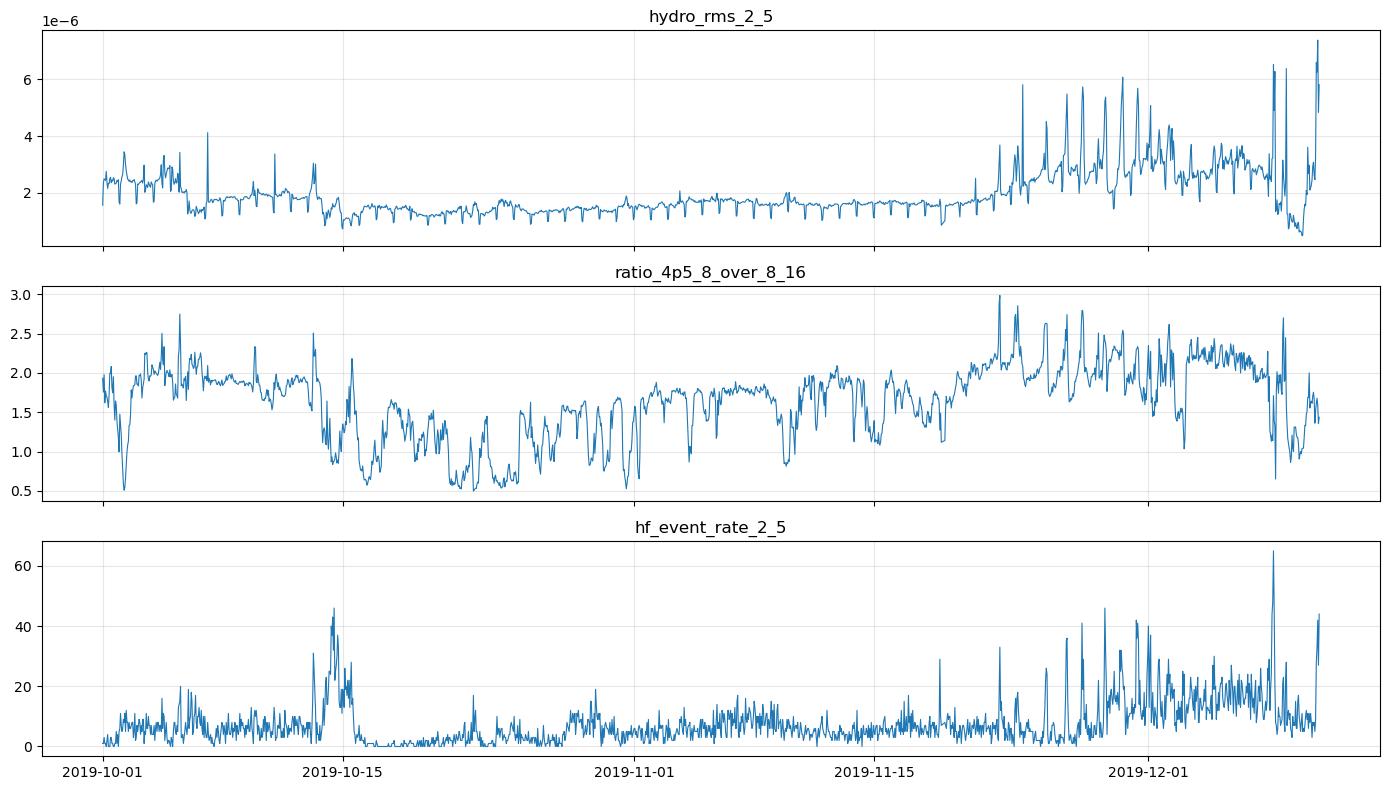

In [130]:
plot_whakaari_waveforms(analysis_df)

#### Trigger/state variables

In [131]:
def plot_whakaari_external(df):
    cols = ["SO2_flux", "GNSS_deformation", "API", "pressure_drop"]

    fig, axes = plt.subplots(len(cols), 1, figsize=(14, 10), sharex=True)
    for ax, col in zip(axes, cols):
        ax.plot(df.index, df[col], linewidth=0.8)
        ax.set_title(col)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

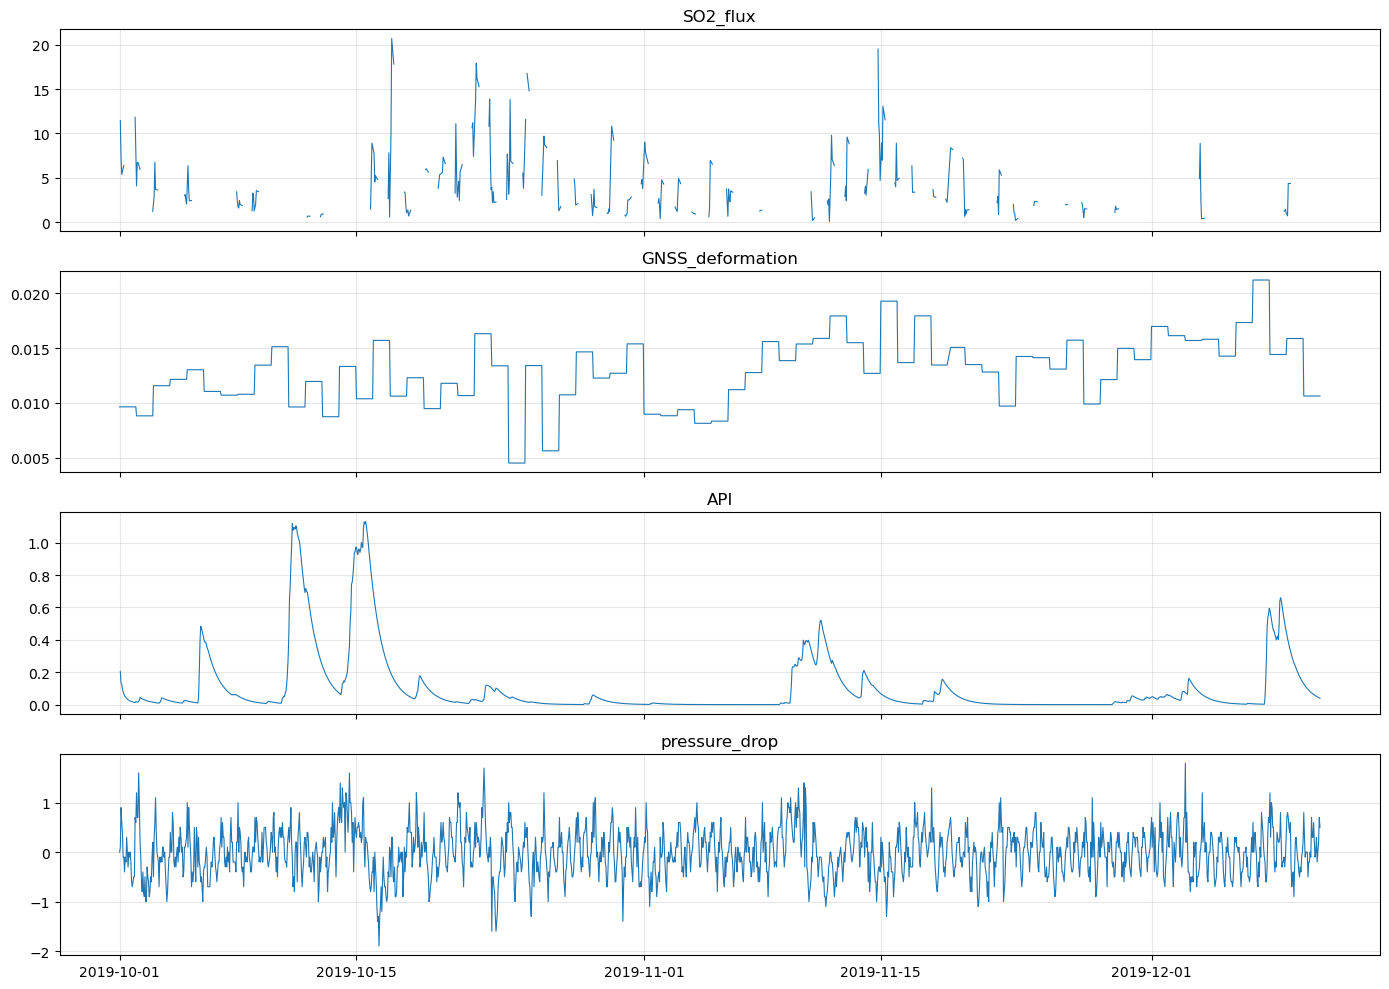

In [132]:
plot_whakaari_external(analysis_df)

#### Scaled version

In [133]:
def plot_whakaari_scaled(df):
    cols = [c for c in df.columns if c != "eruption"]

    fig, axes = plt.subplots(len(cols), 1, figsize=(14, 2.2 * len(cols)), sharex=True)
    if len(cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, cols):
        ax.plot(df.index, df[col], linewidth=0.8)
        ax.set_title(col)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

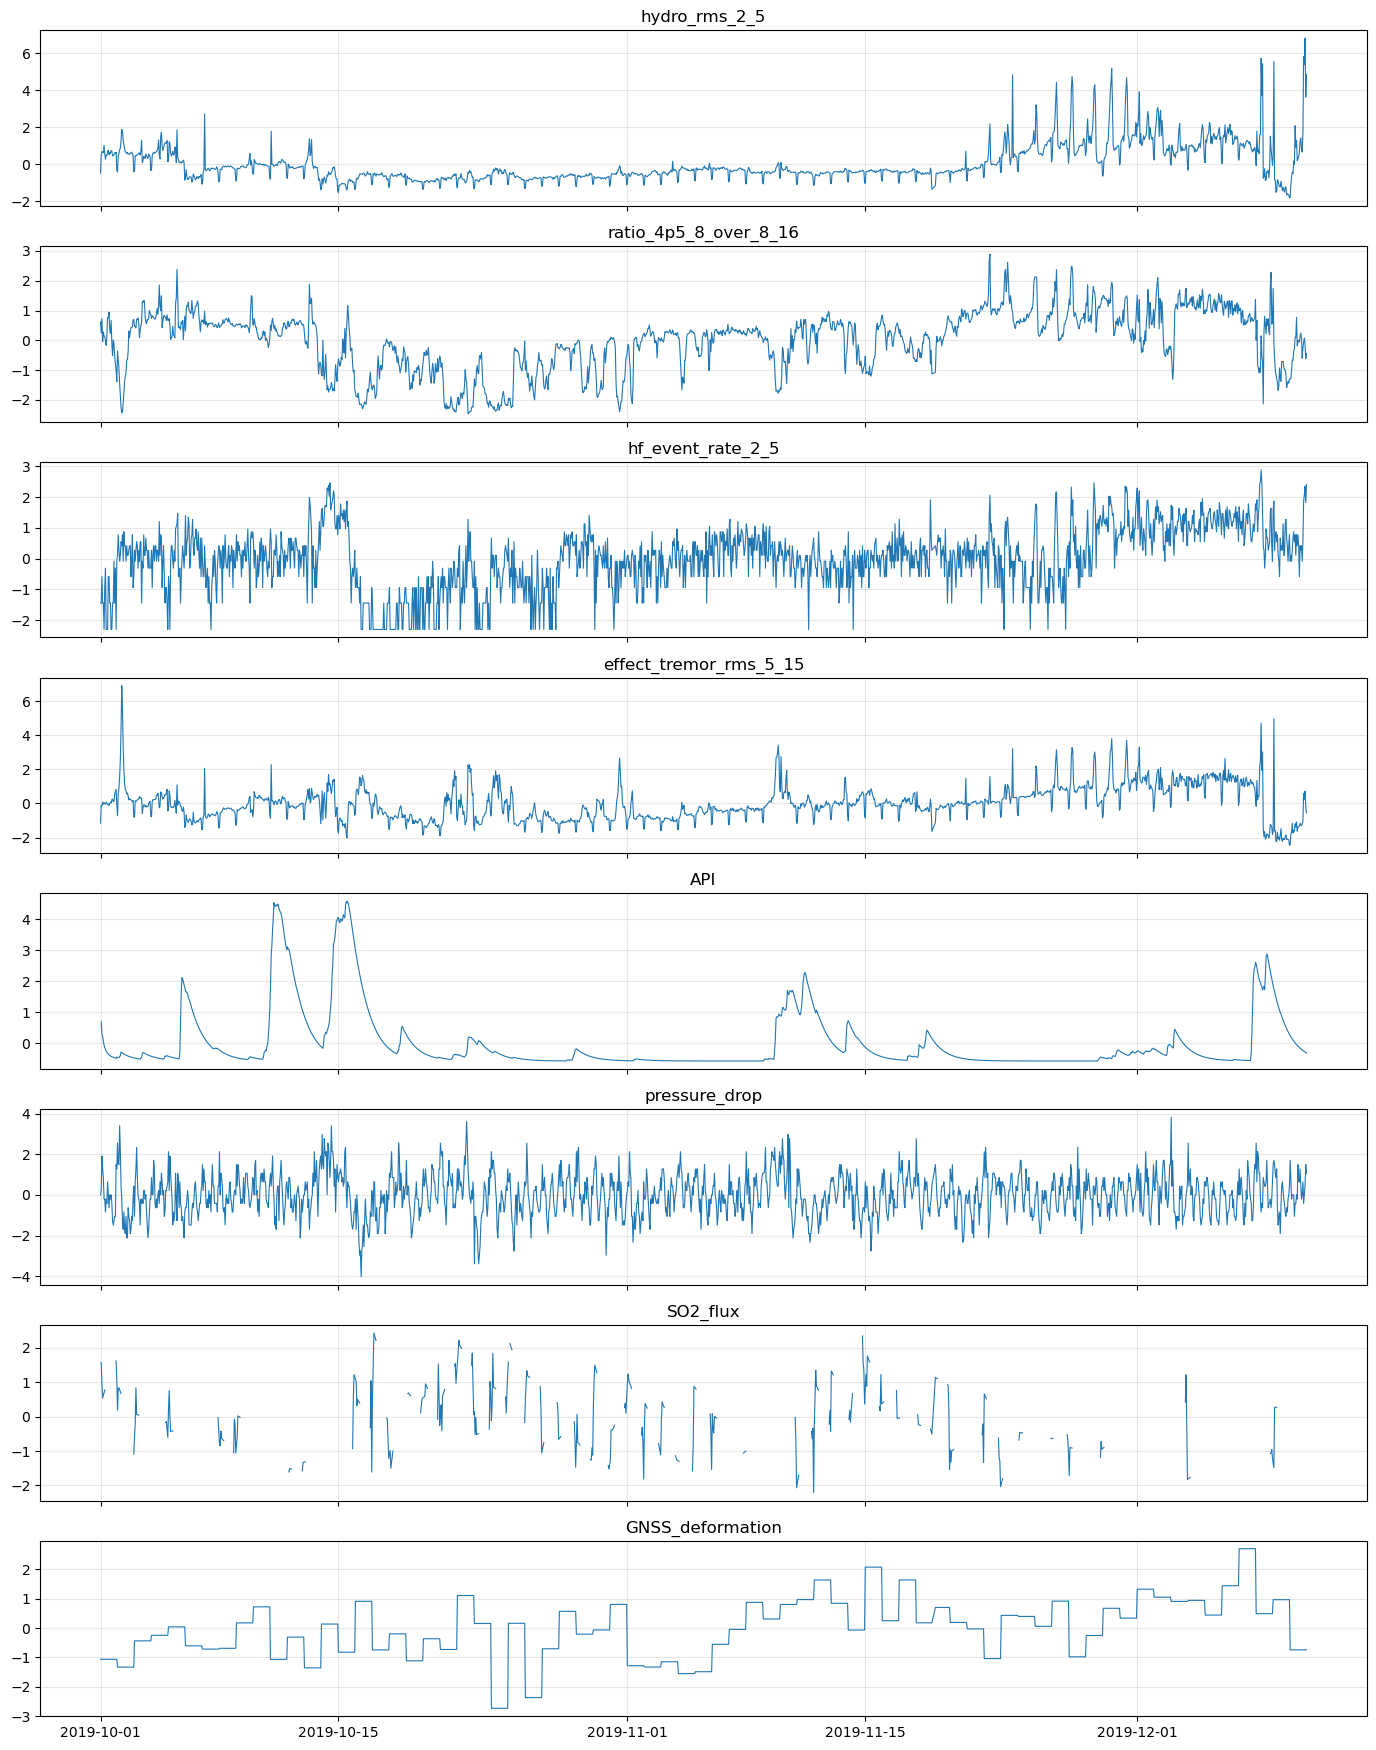

In [134]:
plot_whakaari_scaled(analysis_scaled)

#### Eruption marker plot

In [135]:
def plot_with_eruption_time(df, cols, eruption_time):
    fig, axes = plt.subplots(len(cols), 1, figsize=(14, 2.8 * len(cols)), sharex=True)
    if len(cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, cols):
        ax.plot(df.index, df[col], linewidth=0.8)
        ax.axvline(eruption_time, color="red", linestyle="--", alpha=0.7)
        ax.set_title(col)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

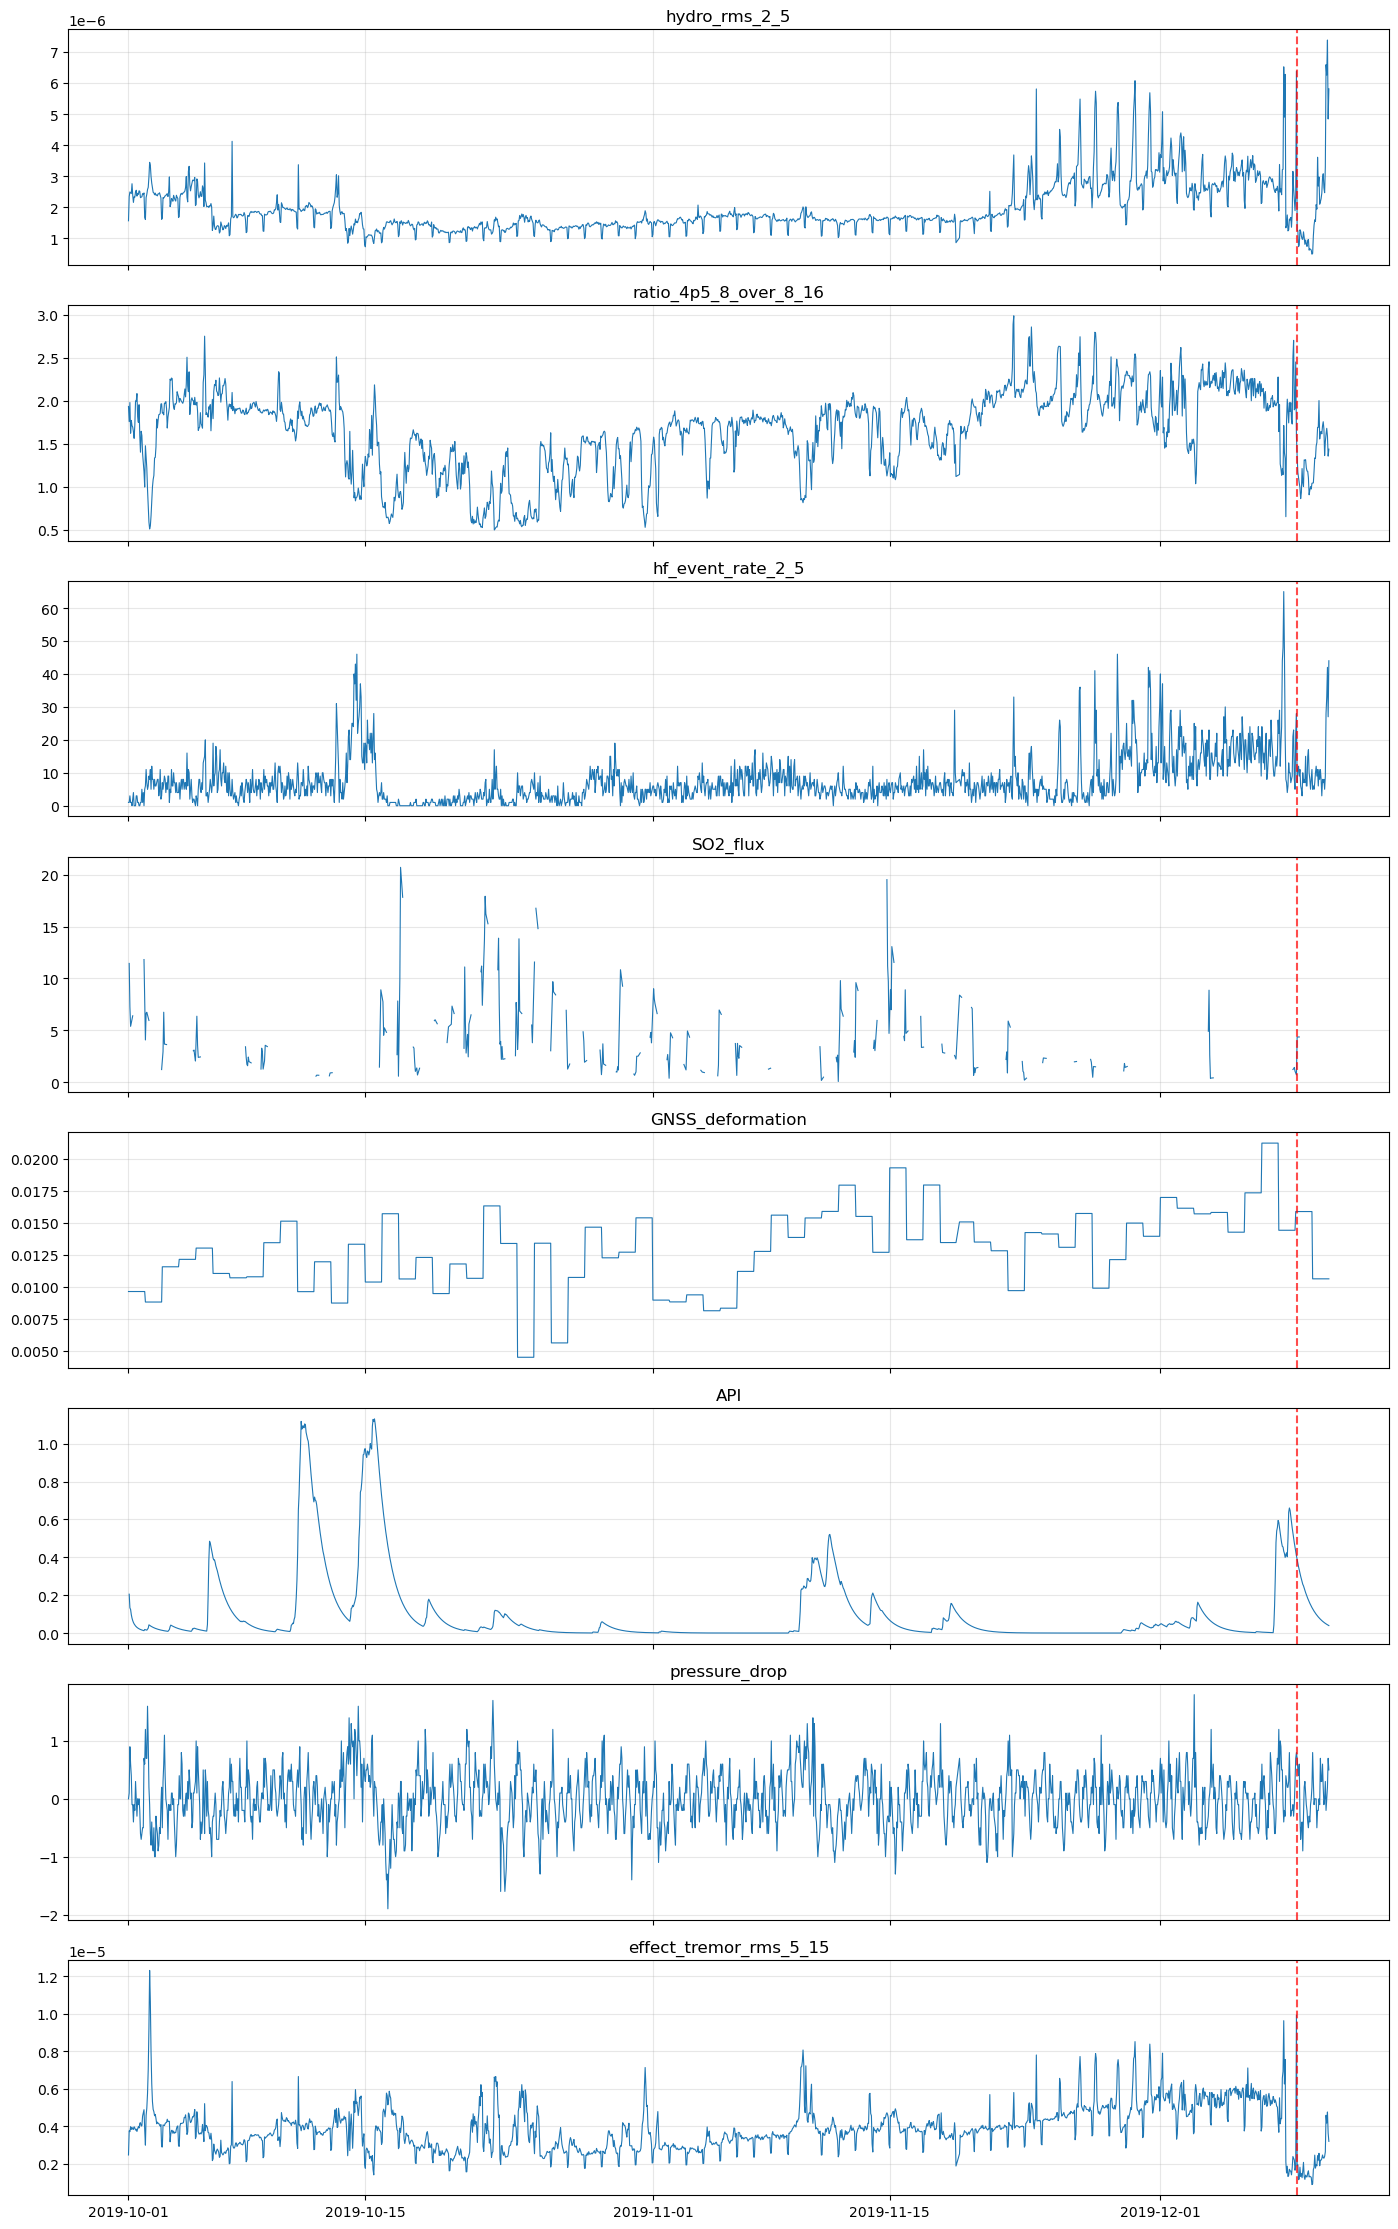

In [136]:
plot_with_eruption_time(
    analysis_df,
    [
        "hydro_rms_2_5",
        "ratio_4p5_8_over_8_16",
        "hf_event_rate_2_5",
        "SO2_flux",
        "GNSS_deformation",
        "API",
        "pressure_drop",
        "effect_tremor_rms_5_15",
    ],
    eruption_time
)